In [15]:
pip install pymysql sqlalchemy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
from sqlalchemy import create_engine

In [17]:
%pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [18]:
# 1) 접속 정보 설정
USER = "root"          # MySQL 계정
PASSWORD = "123456"
HOST = "localhost"     # 도커 컨테이너를 호스트로 포워딩했으면 보통 localhost
PORT = "3400"          # docker run -p 3306:3306 했다고 가정
DB = "docker_mysql"   # 사용 중인 DB 이름

In [ ]:
# 2) SQLAlchemy 엔진 생성
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}?charset=utf8mb4")

In [ ]:
query = """
select 
    reason,
    count(block_user_id) as block_count
from accounts_blockrecord
group by reason
;
"""

In [9]:
# 4) pandas DataFrame으로 읽어오기
df = pd.read_sql(query, con=engine)
df.head()

,reason,block_count
0,그냥...,6
1,친구 사이가 어색해짐,5805
2,나랑 관련 없는 질문을 자꾸 보냄,1083
3,기타,7
4,모르는 사람임,9640


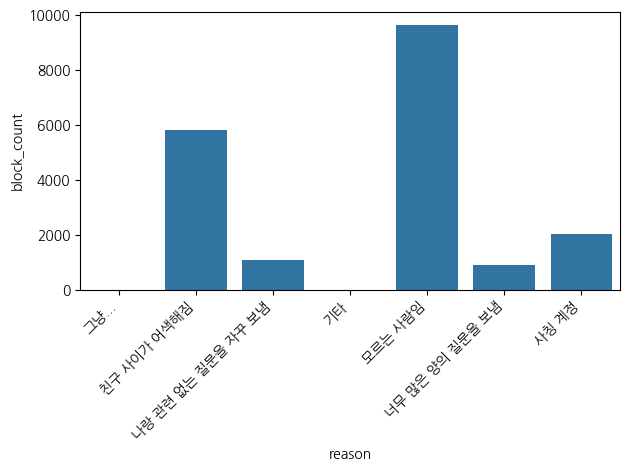

In [17]:
# 차단 이유별 차단 수
sns.barplot(
    data=df,
    x='reason',
    y='block_count'
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
failpayment_query = """
SELECT
    productId,
    COUNT(created_at) as count
FROM accounts_failpaymenthistory
GROUP BY productId
"""

failpayment_df = pd.read_sql(failpayment_query, con=engine)
failpayment_df.head()


,productId,count
0,heart.200,3
1,heart.777,49
2,heart.1000,4
3,None,107


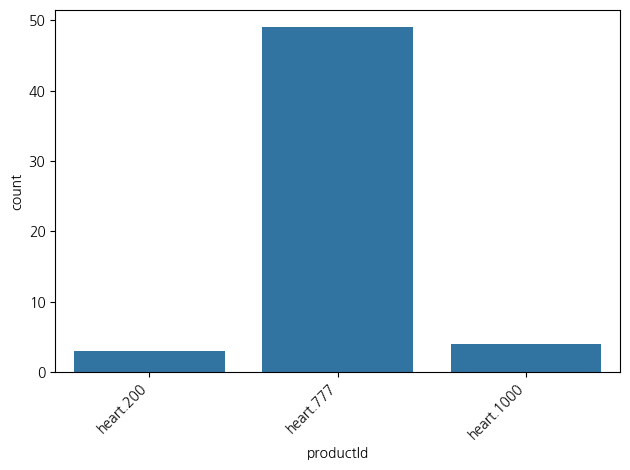

In [22]:
# 상품 별 구매 실패 수
sns.barplot(
    data=failpayment_df,
    x='productId',
    y='count'
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
payment_by_month_query = """
SELECT 
    YEAR(created_at) AS year,
    MONTH(created_at) AS month,
    COUNT(created_at) AS purchase_count
FROM accounts_paymenthistory
GROUP BY 1, 2
;
"""

purchase_by_month_df = pd.read_sql(payment_by_month_query, con=engine)
purchase_by_month_df.head()

,year,month,purchase_count
0,2023,5,82188
1,2023,6,7709
2,2023,7,2227
3,2023,8,1418
4,2023,9,520


In [11]:
purchase_by_month_df['year'] = purchase_by_month_df['year'].astype('str')
purchase_by_month_df['month'] = purchase_by_month_df['month'].astype('str')
purchase_by_month_df['year-month'] = purchase_by_month_df['year'] + '-' + purchase_by_month_df['month']
purchase_by_month_df.head()

,year,month,purchase_count,year-month
0,2023,5,82188,2023-5
1,2023,6,7709,2023-6
2,2023,7,2227,2023-7
3,2023,8,1418,2023-8
4,2023,9,520,2023-9


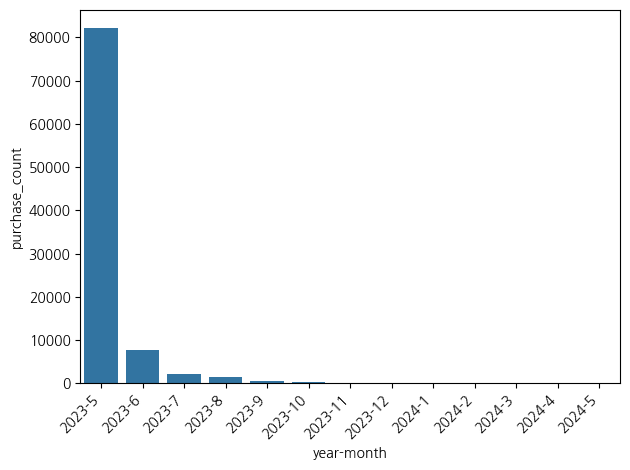

In [14]:
# 월별 하트 구매 건수
sns.barplot(
    data=purchase_by_month_df,
    x='year-month',
    y='purchase_count'
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
number_by_date_query = """
SELECT
    DATE(created_at) AS date,
    COUNT(question_text) AS count
FROM polls_question
GROUP BY date
"""

number_by_date_df = pd.read_sql(number_by_date_query, con=engine)
number_by_date_df.head()

,date,count
0,2023-03-31,73
1,2023-04-01,154
2,2023-05-02,235
3,2023-05-04,1
4,2023-05-11,91


In [21]:
number_by_date_df

,date,count
0,2023-03-31,73
1,2023-04-01,154
2,2023-05-02,235
3,2023-05-04,1
4,2023-05-11,91
5,2023-05-15,982
6,2023-06-02,1523
7,2023-06-06,1966
